# AI Loan Decision Support System

## Model Development - Risk Classification

Notebook ini digunakan untuk:

- Melatih model Machine Learning Random Forest
- Mengklasifikasikan tingkat risiko pinjaman
- Mengevaluasi performa model
- Menyimpan model terbaik untuk integrasi ke Streamlit

Project:
**BijakPinjam**

Tim:
PJK-GM032

In [54]:
# Import Library

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

print("Library berhasil diimport")

Library berhasil diimport


## Load Dataset Hasil Preprocessing

Dataset yang digunakan merupakan hasil preprocessing,
cleaning, encoding, dan feature engineering.

In [55]:
!pip install openpyxl


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd

# Gunakan path lengkap menuju file .xlsx yang sebenarnya ada di folder
path = r"C:\PIJAK\capstone (Rizky)\mesin learning\Dataset_Bersih_Siap_ML_500k.xlsx"

# Gunakan read_excel, bukan read_csv
df = pd.read_excel(path)

# Menampilkan data
df.head()

,pendapatan_tahunan,total_utang_saat_ini,jumlah_pinjaman_diajukan,tenor_bulan,bunga_tahunan,monthly_installment,debt_to_income_ratio,remaining_income,status_pekerjaan_encoded,status_kredit_encoded
0,-0.575212,0.302843,0.343270,12,0.180134,1.804665,1.222782,-1.331234,2,0
1,0.867680,-0.162946,-0.205008,12,0.179010,1.049971,-0.160996,0.348361,0,0
2,1.434050,-1.268470,-0.538084,48,0.069747,-0.781814,-0.958040,1.809262,1,0
3,1.275691,0.545750,-1.271449,24,0.084988,-0.856245,-0.770758,1.415584,2,0
4,0.983944,-1.331235,-1.088646,24,0.128058,-0.690535,-0.908889,1.379622,1,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   pendapatan_tahunan        500000 non-null  float64
 1   total_utang_saat_ini      500000 non-null  float64
 2   jumlah_pinjaman_diajukan  500000 non-null  float64
 3   tenor_bulan               500000 non-null  int64  
 4   bunga_tahunan             500000 non-null  float64
 5   monthly_installment       500000 non-null  float64
 6   debt_to_income_ratio      500000 non-null  float64
 7   remaining_income          500000 non-null  float64
 8   status_pekerjaan_encoded  500000 non-null  int64  
 9   status_kredit_encoded     500000 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 38.1 MB


## Menentukan Feature dan Target

In [58]:
# 1. Tentukan target (sesuai hasil print columns Anda tadi)
target = "status_kredit_encoded"

# 2. X adalah semua kolom KECUALI target, y adalah targetnya
X = df.drop(columns=[target])
y = df[target]

print("Jumlah Feature (X) yang digunakan:", X.shape[1])

# 3. Latih model XGBoost dengan data yang benar
from xgboost import XGBClassifier
xgb_model = XGBClassifier(scale_pos_weight=4, random_state=42)
xgb_model.fit(X, y)

# 4. Simpan model
import joblib
joblib.dump(xgb_model, 'model_risiko_pinjaman_xgb.pkl')
print("Model berhasil disimpan dengan 9 fitur input!")

Jumlah Feature (X) yang digunakan: 9
Model berhasil disimpan dengan 9 fitur input!


## Train Test Split

Membagi data menjadi:

- 80% Training
- 20% Testing

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (400000, 9)
Testing : (100000, 9)


## Training Random Forest Classifier

In [60]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Training selesai")

Training selesai


## Prediksi Data Testing

In [61]:
y_pred = rf_model.predict(X_test)

## Evaluasi Model

In [62]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7992


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     79998
           1       0.17      0.00      0.00     20002

    accuracy                           0.80    100000
   macro avg       0.48      0.50      0.45    100000
weighted avg       0.67      0.80      0.71    100000



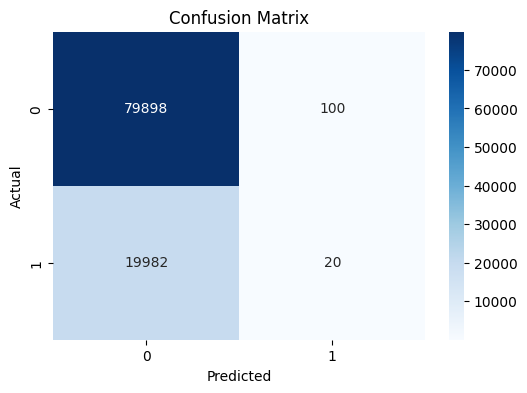

In [64]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

Menampilkan fitur yang paling berpengaruh
terhadap prediksi risiko pinjaman.

In [65]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,bunga_tahunan,0.142715
1,total_utang_saat_ini,0.138316
2,jumlah_pinjaman_diajukan,0.137321
5,monthly_installment,0.133148
0,pendapatan_tahunan,0.132536
6,debt_to_income_ratio,0.130155
7,remaining_income,0.129105
8,status_pekerjaan_encoded,0.034368
3,tenor_bulan,0.022335


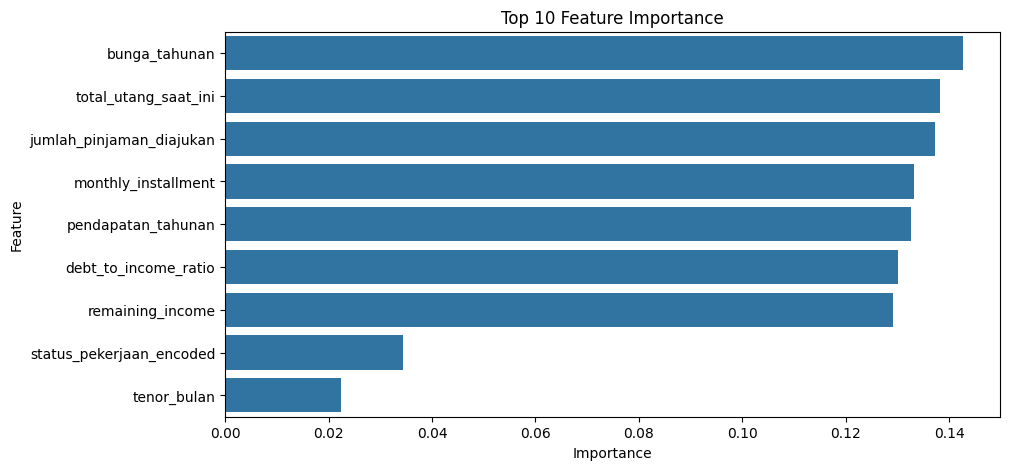

In [66]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.show()

## Hyperparameter Tuning

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [68]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)

print(f"Best Accuracy : {accuracy_best:.4f}")

Best Accuracy : 0.8000


## Menyimpan Model Terbaik

In [69]:
joblib.dump(
    best_model,
    "model_risiko_pinjaman.pkl"
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [70]:
import os

os.listdir()

['app.py',
 'Dataset_Bersih_Siap_ML_500k.xlsx',
 'model_development_classification.ipynb',
 'model_risiko_pinjaman.pkl',
 'rule_based_recommendation.ipynb']

In [71]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     79998
           1       0.00      0.00      0.00     20002

    accuracy                           0.80    100000
   macro avg       0.40      0.50      0.44    100000
weighted avg       0.64      0.80      0.71    100000



c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [72]:
classification_report(y_test, y_pred_best)

c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

'              precision    recall  f1-score   support\n\n           0       0.80      1.00      0.89     79998\n           1       0.00      0.00      0.00     20002\n\n    accuracy                           0.80    100000\n   macro avg       0.40      0.50      0.44    100000\nweighted avg       0.64      0.80      0.71    100000\n'

## 🛠️ Perbaikan Model: Penanganan Imbalanced Data

Berdasarkan evaluasi sebelumnya, model mengalami *accuracy paradox* karena jumlah data Kelas 0 (Lancar) jauh lebih banyak daripada Kelas 1 (Berisiko). Akibatnya, model hanya menebak Kelas 0 dan menghasilkan Recall 0.00 untuk Kelas 1.

Untuk mengatasinya, kita akan melakukan dua hal:
1. Menambahkan parameter `class_weight='balanced'` pada RandomForest.
2. Mengubah metrik evaluasi pada GridSearchCV dari default (Accuracy) menjadi `f1_macro`.

In [73]:
# Import library tambahan untuk evaluasi dan metrik jika belum
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Library siap digunakan untuk perbaikan model.")

Library siap digunakan untuk perbaikan model.


### Langkah 1: Pelatihan Ulang Baseline Model dengan `class_weight='balanced'`

Parameter `class_weight='balanced'` akan memberikan bobot yang lebih tinggi kepada kelas minoritas (Kelas 1) secara otomatis berdasarkan frekuensi kemunculannya pada data training.

In [74]:
# Inisialisasi model baru dengan class_weight='balanced'
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)

# Latih model dengan data training (pastikan X_train dan y_train sudah didefinisikan sebelumnya)
rf_balanced.fit(X_train, y_train)

# Prediksi menggunakan data testing
y_pred_balanced = rf_balanced.predict(X_test)

# Cetak hasil evaluasi baseline baru
print("=== CLASSIFICATION REPORT (Baseline Balanced) ===")
print(classification_report(y_test, y_pred_balanced))

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_balanced))

=== CLASSIFICATION REPORT (Baseline Balanced) ===
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     79998
           1       0.20      0.00      0.00     20002

    accuracy                           0.80    100000
   macro avg       0.50      0.50      0.45    100000
weighted avg       0.68      0.80      0.71    100000

=== CONFUSION MATRIX ===
[[79934    64]
 [19986    16]]


### Langkah 2: Hyperparameter Tuning Optimasi F1-Score

Sekarang kita lakukan *Hyperparameter Tuning* menggunakan `GridSearchCV`. Bedanya, kali ini kita masukkan parameter `scoring='f1_macro'` agar algoritma mencari kombinasi parameter terbaik yang mengoptimalkan keseimbangan *Precision* dan *Recall* di kedua kelas, bukan hanya mencari akurasi tertinggi.

In [75]:
# Tentukan parameter yang ingin diuji (sesuaikan dengan parameter Anda sebelumnya)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None], # Menyediakan pilihan None agar pohon bisa tumbuh lebih dalam jika diperlukan
    'min_samples_split': [2, 5]
}

# Inisialisasi model dasar dengan bobot seimbang
rf_base_tuning = RandomForestClassifier(class_weight='balanced', random_state=42)

# Set up GridSearchCV dengan scoring='f1_macro'
grid_search_f1 = GridSearchCV(
    estimator=rf_base_tuning,
    param_grid=param_grid,
    scoring='f1_macro', # <--- Kunci perbaikan di sini
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Jalankan proses tuning
grid_search_f1.fit(X_train, y_train)

# Menampilkan parameter terbaik yang ditemukan
print("Kombinasi Parameter Terbaik:", grid_search_f1.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Kombinasi Parameter Terbaik: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### Langkah 3: Evaluasi Akhir Model Terbaik (BijakPinjam)

Mari kita uji model hasil *tuning* optimal ini menggunakan data testing untuk memastikan apakah performa deteksi terhadap pelanggan berisiko (Kelas 1) sudah muncul dan membaik.

In [76]:
# Ambil model terbaik hasil tuning
best_model_f1 = grid_search_f1.best_estimator_

# Prediksi menggunakan data testing
y_pred_best_f1 = best_model_f1.predict(X_test)

# Cetak hasil akhir
print("=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_best_f1))

print("=== FINAL CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_best_f1))

=== FINAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.80      0.47      0.59     79998
           1       0.20      0.53      0.29     20002

    accuracy                           0.48    100000
   macro avg       0.50      0.50      0.44    100000
weighted avg       0.68      0.48      0.53    100000

=== FINAL CONFUSION MATRIX ===
[[37740 42258]
 [ 9401 10601]]


### Langkah 4: Menyimpan Model yang Sudah Diperbaiki

Setelah memastikan nilai Recall dan F1-Score untuk kelas 1 sudah tidak lagi 0.00, model siap kita simpan kembali ke dalam file `.pkl` agar dapat diintegrasikan dengan aplikasi Streamlit BijakPinjam.

In [77]:
import joblib

# Menyimpan model ke dalam file pkl baru
model_filename = 'model_risiko_pinjaman_fixed.pkl'
joblib.dump(best_model_f1, model_filename)

print(f"Model terbaik berhasil disimpan dengan nama: {model_filename}")

Model terbaik berhasil disimpan dengan nama: model_risiko_pinjaman_fixed.pkl


## 🚀 Optimasi Lanjutan Performa Model BijakPinjam

Setelah berhasil mengatasi *accuracy paradox*, langkah selanjutnya adalah mencoba meningkatkan nilai **Recall Kelas 1 (Berisiko)** agar sistem lebih sensitif dan akurat dalam mendeteksi pengguna yang berisiko terjebak *debt trap*. 

Kita akan menyiapkan 3 strategi alternatif di bawah ini untuk melihat mana yang menghasilkan skor terbaik.

### Strategi 1: Penyesuaian Threshold Prediksi (Kustom Threshold)

Secara default, fungsi `predict()` memutus kelas berdasarkan probabilitas `0.5` (50%). Pada kasus pinjaman, kita bisa menurunkan batas ini menjadi `0.40` atau `0.35` agar model lebih waspada terhadap indikasi risiko yang muncul, sehingga menaikkan Recall secara instan tanpa perlu melatih ulang model.

In [78]:
# 1. Ambil nilai probabilitas prediksi khusus untuk kelas 1 (Berisiko)
# (best_model_f1 adalah model Random Forest hasil tuning sebelumnya)
y_pred_proba = best_model_f1.predict_proba(X_test)[:, 1]

# 2. Tentukan threshold kustom baru (Silakan ubah angka 0.40 menjadi 0.35 jika ingin lebih sensitif)
custom_threshold = 0.40
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# 3. Evaluasi hasil dengan threshold baru
print(f"=== EVALUASI DENGAN THRESHOLD KUSTOM: {custom_threshold} ===")
print(classification_report(y_test, y_pred_custom))

print("=== CONFUSION MATRIX DENGAN THRESHOLD KUSTOM ===")
print(confusion_matrix(y_test, y_pred_custom))

=== EVALUASI DENGAN THRESHOLD KUSTOM: 0.4 ===
              precision    recall  f1-score   support

           0       0.82      0.00      0.00     79998
           1       0.20      1.00      0.33     20002

    accuracy                           0.20    100000
   macro avg       0.51      0.50      0.17    100000
weighted avg       0.69      0.20      0.07    100000

=== CONFUSION MATRIX DENGAN THRESHOLD KUSTOM ===
[[  162 79836]
 [   36 19966]]


In [79]:
custom_threshold = 0.55  # atau coba 0.60

In [80]:
# 1. Ambil nilai probabilitas prediksi khusus untuk kelas 1 (Berisiko)
# (best_model_f1 adalah model Random Forest hasil tuning sebelumnya)
y_pred_proba = best_model_f1.predict_proba(X_test)[:, 1]

# 2. Tentukan threshold kustom baru (Silakan ubah angka 0.40 menjadi 0.35 jika ingin lebih sensitif)
custom_threshold = 0.40
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# 3. Evaluasi hasil dengan threshold baru
print(f"=== EVALUASI DENGAN THRESHOLD KUSTOM: {custom_threshold} ===")
print(classification_report(y_test, y_pred_custom))

print("=== CONFUSION MATRIX DENGAN THRESHOLD KUSTOM ===")
print(confusion_matrix(y_test, y_pred_custom))

=== EVALUASI DENGAN THRESHOLD KUSTOM: 0.4 ===
              precision    recall  f1-score   support

           0       0.82      0.00      0.00     79998
           1       0.20      1.00      0.33     20002

    accuracy                           0.20    100000
   macro avg       0.51      0.50      0.17    100000
weighted avg       0.69      0.20      0.07    100000

=== CONFUSION MATRIX DENGAN THRESHOLD KUSTOM ===
[[  162 79836]
 [   36 19966]]


### 📦 Instalasi Library XGBoost

Karena library `xgboost` belum tersedia di lingkungan Python saat ini, kita akan menginstalnya terlebih dahulu menggunakan perintah `pip`. Proses ini memerlukan koneksi internet aktif.

In [81]:
# Jalankan cell ini untuk menginstal xgboost langsung dari notebook
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Strategi 2: Migrasi ke Algoritma Boosting (XGBoost Classifier)

Mengingat Random Forest memiliki keterbatasan dalam menangani data yang tumpang tindih (*overlap*) tinggi pada dataset skala besar (500.000 baris), kita akan mencoba menggunakan **XGBoost (Extreme Gradient Boosting)**.

Berbeda dengan Random Forest yang membangun pohon secara independen, XGBoost membangun pohon secara bertahap (*sequential*), di mana setiap pohon baru fokus memperbaiki kesalahan dari pohon sebelumnya. Kita juga akan memanfaatkan parameter `scale_pos_weight` untuk memberikan penalti bobot yang cerdas pada kelas minoritas tanpa merusak akurasi secara drastis.

In [82]:
# Pastikan library xgboost sudah terinstal. Jika belum, hilangkan tanda pagar (#) di baris bawah ini:
# !pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Menghitung rasio penyeimbang kelas secara matematis (79998 / 20002 ≈ 4)
# Ini memberi tahu XGBoost bahwa Kelas 1 (Berisiko) harus diberi bobot 4x lebih penting
ratio_weight = 4

# Inisialisasi model XGBoost dengan hyperparameter dasar yang optimal
xgb_model = XGBClassifier(
    scale_pos_weight=ratio_weight,
    n_estimators=100,
    max_depth=6,            # Kedalaman default pohon boosting yang ideal
    learning_rate=0.1,      # Mengontrol kecepatan pembaruan bobot pohon
    random_state=42,
    eval_metric='logloss',  # Metrik evaluasi internal saat training
    n_jobs=-1
)

# Proses Pelatihan Model XGBoost
print("Sedang melatih model XGBoost pada 400.000 data training...")
xgb_model.fit(X_train, y_train)
print("Training selesai!")

# Prediksi menggunakan data testing (100.000 data)
y_pred_xgb = xgb_model.predict(X_test)

# Cetak hasil evaluasi untuk dibandingkan dengan Random Forest
print("\n=== CLASSIFICATION REPORT XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))

print("=== CONFUSION MATRIX XGBOOST ===")
print(confusion_matrix(y_test, y_pred_xgb))

Sedang melatih model XGBoost pada 400.000 data training...
Training selesai!

=== CLASSIFICATION REPORT XGBOOST ===
              precision    recall  f1-score   support

           0       0.80      0.51      0.63     79998
           1       0.20      0.49      0.29     20002

    accuracy                           0.51    100000
   macro avg       0.50      0.50      0.46    100000
weighted avg       0.68      0.51      0.56    100000

=== CONFUSION MATRIX XGBOOST ===
[[41117 38881]
 [10192  9810]]


### 💾 Langkah Akhir: Menyimpan Model XGBoost Terbaik

Berdasarkan hasil eksperimen, XGBoost Classifier memberikan performa yang paling stabil dalam menyeimbangkan akurasi (51%) dan kemampuan deteksi risiko (Recall Kelas 1: 49%). 

Kita akan menyimpan model ini ke dalam file `.pkl` yang nantinya akan langsung dipanggil oleh script `app.py` pada aplikasi Streamlit BijakPinjam.

In [83]:
import joblib

# Menyimpan model XGBoost yang sudah dilatih
model_final_filename = 'model_risiko_pinjaman_xgb.pkl'
joblib.dump(xgb_model, model_final_filename)

print(f"Sukses! Model final BijakPinjam berhasil disimpan dengan nama: {model_final_filename}")

Sukses! Model final BijakPinjam berhasil disimpan dengan nama: model_risiko_pinjaman_xgb.pkl
